In [53]:

import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
import torch


In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import seaborn as sns
from itertools import cycle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
DATASET_PATH = "/content/drive/MyDrive/brain_tumor/data"   # train / val / test
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-4

In [57]:
train_transform = transforms.Compose([
    # Görüntüyü  yeniden boyutlandır
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    # Gri tonlamalı görüntüleri 3 kanallı (RGB) formata dönüştür
    transforms.Grayscale(num_output_channels=3),

    # Rastgele afin dönüşüm uygula (veri artırma)
    # degrees: ±10 derece döndürme
    # translate: %5 yatay/dikey kaydırma
    # scale: %95-105 arası ölçekleme
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR
    ),

    # %40 olasılıkla parlaklık ve kontrast değişikliği uygula
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2)
    ], p=0.4),

    # %10 olasılıkla Gaussian bulanıklık ekle
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.1),

    # PIL görüntüsünü PyTorch tensörüne dönüştür (0-255 -> 0-1)
    transforms.ToTensor(),

    # %30 olasılıkla rastgele Gaussian gürültü ekle
    # Modelin gürültüye karşı dayanıklılığını artırır
    transforms.RandomApply([
        transforms.Lambda(lambda x: x + 0.02 * torch.randn_like(x))
    ], p=0.3),

    # Piksel değerlerini normalize et: (x - 0.5) / 0.5 -> [-1, 1] aralığına
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [58]:
val_transform = transforms.Compose([

    #  grayscale'i RGB'ye çeviriyoruz 
    transforms.Grayscale(num_output_channels=3),
    
    # Tüm görselleri aynı boyuta getiriyoruz 
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    # PIL image'ı tensor'a çeviriyoruz
    transforms.ToTensor(),
    
    # Train ile aynı normalizasyonu uyguluyoruz
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [59]:
from torch.utils.data import random_split, Subset

# Eğitim ve test klasör yollarını oluştur
train_dir = os.path.join(DATASET_PATH, "Train")
test_dir = os.path.join(DATASET_PATH, "Test")

# Test veri setini yükle (augmentasyon yok, sadece resize ve normalize)
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_transform
)

# Eğitim verilerini yükle (augmentasyonlu ve augmentasyonsuz iki versiyon)
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
full_val_dataset_source = datasets.ImageFolder(train_dir, transform=val_transform)

# %80 eğitim, %20 doğrulama olarak böl
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Tekrarlanabilirlik için sabit seed kullan
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# Eğitim seti (augmentasyonlu)
train_dataset = train_subset

# Doğrulama seti (aynı indeksler ama augmentasyonsuz)
val_dataset = Subset(full_val_dataset_source, val_subset.indices)

# DataLoader'ları oluştur
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Sınıf sayısı ve isimleri
num_classes = len(full_train_dataset.classes)
class_names = full_train_dataset.classes

# Veri seti boyutlarını yazdır
print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Classes: {class_names}")

Train dataset size: 7720
Val dataset size: 1930
Test dataset size: 2414
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


***EfficientNet-B0 + MobileNetV2***

In [60]:
class EfficientNet_MobileNet_Hybrid(nn.Module):
    """EfficientNet-B0 ve MobileNetV2'yi birleştiren hibrit model"""
    
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()

        # Önceden eğitilmiş modelleri yükle
        self.efficientnet = models.efficientnet_b0(pretrained=True)
        self.mobilenet = models.mobilenet_v2(pretrained=True)

        # Sadece özellik çıkarıcı katmanları al
        self.efficientnet_features = self.efficientnet.features
        self.mobilenet_features = self.mobilenet.features

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # İki modelin çıktılarını birleştir (1280 + 1280 = 2560)
        fused_dim = 1280 + 1280

        # Sınıflandırıcı katmanları
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),      # Boyut azaltma
            nn.BatchNorm1d(512),            # Normalizasyon
            nn.ReLU(),                      # Aktivasyon
            nn.Dropout(dropout),            # Aşırı öğrenmeyi önle
            nn.Linear(512, num_classes)     # Çıkış katmanı
        )

        # Tüm backbone ağırlıklarını dondur
        for param in self.efficientnet_features.parameters():
            param.requires_grad = False
        for param in self.mobilenet_features.parameters():
            param.requires_grad = False

        # Son 2 katmanı eğitilebilir yap (fine-tuning)
        for param in self.efficientnet_features[-2:].parameters():
            param.requires_grad = True
        for param in self.mobilenet_features[-2:].parameters():
            param.requires_grad = True

    def forward(self, x):
        # EfficientNet'ten özellik çıkar
        ef = self.efficientnet_features(x)
        ef = self.pool(ef)
        ef = ef.view(ef.size(0), -1)  # Düzleştir

        # MobileNet'ten özellik çıkar
        mb = self.mobilenet_features(x)
        mb = self.pool(mb)
        mb = mb.view(mb.size(0), -1)  # Düzleştir

        # İki özelliği birleştir
        fused = torch.cat((ef, mb), dim=1)

        # Sınıflandır ve sonucu döndür
        return self.classifier(fused)

**Multi-Scale EfficientNet (Early + Late Fusion)**

In [61]:
class MultiScale_EffNet(nn.Module):
    """Çoklu ölçekli EfficientNet - Erken ve geç füzyon"""
    
    def __init__(self, num_classes):
        super().__init__()

        # EfficientNet-B0 özellik çıkarıcıyı yükle
        eff = models.efficientnet_b0(pretrained=True).features

        # Giriş katmanı (stem)
        self.stem = eff[0]

        # Düşük seviye özellikler (kenarlar, dokular)
        self.low = nn.Sequential(*eff[1:3])
        
        # Orta seviye özellikler (şekiller, desenler)
        self.mid = nn.Sequential(*eff[3:5])
        
        # Yüksek seviye özellikler (semantik bilgi)
        self.high = nn.Sequential(*eff[5:])

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Sınıflandırıcı (24 + 80 + 1280 = 1384 boyutlu birleşik özellik)
        self.fc = nn.Sequential(
            nn.Linear(24 + 80 + 1280, 512),  # Boyut azaltma
            nn.ReLU(),                        # Aktivasyon
            nn.Dropout(0.5),                  # Aşırı öğrenmeyi önle
            nn.Linear(512, num_classes)       # Çıkış katmanı
        )

    def forward(self, x):
        # Giriş katmanından geçir
        x = self.stem(x)

        # Her seviyeden özellik çıkar
        l_feat = self.low(x)          # Düşük seviye
        m_feat = self.mid(l_feat)     # Orta seviye
        h_feat = self.high(m_feat)    # Yüksek seviye

        # Global havuzlama ve düzleştirme
        l = self.pool(l_feat).flatten(1)
        m = self.pool(m_feat).flatten(1)
        h = self.pool(h_feat).flatten(1)

        # Tüm özellikleri birleştir ve sınıflandır
        return self.fc(torch.cat((l, m, h), dim=1))

**EfficientNet-B0 + CBAM + LSTM**




In [62]:
class EffNet_CBAM_LSTM(nn.Module):
    """EfficientNet + Dikkat Mekanizması + LSTM modeli"""
    
    def __init__(self, num_classes, hidden=256):
        super().__init__()

        # EfficientNet-B0 özellik çıkarıcı
        self.eff = models.efficientnet_b0(pretrained=True).features
        
        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Çok başlı dikkat mekanizması (8 kafa, 1280 boyut)
        self.attn = nn.MultiheadAttention(1280, 8, batch_first=True)
        
        # LSTM katmanı (sıralı bağımlılık öğrenme)
        self.lstm = nn.LSTM(1280, hidden, batch_first=True)

        # Çıkış katmanı
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # EfficientNet ile özellik çıkar, havuzla ve düzleştir
        f = self.pool(self.eff(x)).flatten(1).unsqueeze(1)
        
        # Self-attention uygula
        f, _ = self.attn(f, f, f)
        
        # LSTM'den geçir
        o, _ = self.lstm(f)
        
        # Son zaman adımını sınıflandır
        return self.fc(o[:, -1, :])

**DenseNet121 + SE-Attention + LSTM**

In [63]:
class DenseNet_SE_LSTM(nn.Module):
    """DenseNet121 + Squeeze-Excitation + LSTM modeli"""
    
    def __init__(self, num_classes, hidden=256):
        super().__init__()

        # DenseNet121 özellik çıkarıcı (1024 kanal çıktı)
        self.den = models.densenet121(pretrained=True).features
        
        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Squeeze & Excitation bloğu
        # Kanal bazlı dikkat mekanizması - önemli kanalları vurgular
        self.se = nn.Sequential(
            nn.Linear(1024, 256),   # Squeeze: boyut azaltma
            nn.ReLU(),              # Aktivasyon
            nn.Linear(256, 1024),   # Excitation: boyut geri yükleme
            nn.Sigmoid()            # 0-1 arası ağırlık üretimi
        )

        # LSTM katmanı (sıralı bağımlılık öğrenme)
        self.lstm = nn.LSTM(1024, hidden, batch_first=True)

        # Sınıflandırıcı katman
        self.fc = nn.Sequential(
            nn.Dropout(0.4),                # Aşırı öğrenmeyi önle
            nn.Linear(hidden, num_classes)  # Çıkış katmanı
        )

    def forward(self, x):
        # DenseNet ile özellik çıkar ve düzleştir
        f = self.pool(self.den(x)).flatten(1)

        # SE bloğu ile kanal ağırlıkları hesapla
        se_weight = self.se(f)
        f = f * se_weight  # Ağırlıklı özellikler

        # LSTM için boyut ekle (batch, seq_len=1, features)
        f = f.unsqueeze(1)
        o, _ = self.lstm(f)

        # Son zaman adımını sınıflandır
        return self.fc(o[:, -1, :])

**EfficientNet-B0 + Spatial Attention + Residual Fusion**

In [64]:
class EffNet_SpatialAttention_Residual(nn.Module):
    """EfficientNet-B0 + Mekansal Dikkat + Artık Bağlantı modeli"""
    
    def __init__(self, num_classes):
        super().__init__()

        # EfficientNet-B0 özellik çıkarıcı (1280 kanal çıktı)
        self.eff = models.efficientnet_b0(pretrained=True).features

        # Mekansal Dikkat Bloğu
        # Görüntünün hangi bölgelerinin önemli olduğunu öğrenir
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(1280, 256, 1),  # Kanal sayısını azalt
            nn.ReLU(),                 # Aktivasyon
            nn.Conv2d(256, 1, 1),      # Tek kanallı dikkat haritası
            nn.Sigmoid()               # 0-1 arası ağırlık
        )

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Sınıflandırıcı katman
        self.fc = nn.Sequential(
            nn.BatchNorm1d(1280),           # Normalizasyon
            nn.Dropout(0.5),                # Aşırı öğrenmeyi önle
            nn.Linear(1280, num_classes)    # Çıkış katmanı
        )

    def forward(self, x):
        # EfficientNet ile özellik çıkar
        f = self.eff(x)
        
        # Mekansal dikkat haritası hesapla
        attn = self.spatial_attn(f)
        
        # Artık bağlantı ile dikkat uygula
        # f * attn: dikkat ağırlıklı özellikler
        # + f: orijinal özellikleri koru (residual)
        f = f * attn + f

        # Havuzla, düzleştir ve sınıflandır
        f = self.pool(f).flatten(1)
        return self.fc(f)

**Hierarchical CNN + Attention Pooling**

In [65]:
class Hierarchical_CNN_AttnPool(nn.Module):
    """Hiyerarşik CNN + Dikkat Havuzlama modeli"""
    
    def __init__(self, num_classes):
        super().__init__()

        # ResNet18'i önceden eğitilmiş ağırlıklarla yükle
        res = models.resnet18(pretrained=True)

        # ResNet18'i hiyerarşik katmanlara böl
        # Layer1: Giriş + İlk bloklar (64 kanal çıktı)
        self.layer1 = nn.Sequential(*list(res.children())[:5])
        
        # Layer2: İkinci blok (128 kanal çıktı)
        self.layer2 = res.layer2
        
        # Layer3: Üçüncü blok (256 kanal çıktı)
        self.layer3 = res.layer3
        
        # Layer4: Son blok (512 kanal çıktı)
        self.layer4 = res.layer4

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Dikkat ağırlıkları hesaplama katmanı
        # Her hiyerarşi seviyesine önem ağırlığı atar
        self.attn_fc = nn.Sequential(
            nn.Linear(64 + 128 + 256 + 512, 256),  # Toplam: 960 boyut
            nn.ReLU(),
            nn.Linear(256, 4),      # 4 seviye için 4 ağırlık
            nn.Softmax(dim=1)       # Ağırlıkları normalize et
        )

        # Sınıflandırıcı katman (960 boyutlu birleşik özellik)
        self.classifier = nn.Linear(64 + 128 + 256 + 512, num_classes)

    def forward(self, x):
        # Her hiyerarşi seviyesinden özellik çıkar
        # Düşük seviye özellikler (kenarlar, dokular)
        f1 = self.pool(self.layer1(x)).flatten(1)
        
        # Orta-düşük seviye özellikler
        f2 = self.pool(self.layer2(self.layer1(x))).flatten(1)
        
        # Orta-yüksek seviye özellikler
        f3 = self.pool(self.layer3(self.layer2(self.layer1(x)))).flatten(1)
        
        # Yüksek seviye özellikler (semantik bilgi)
        f4 = self.pool(self.layer4(self.layer3(self.layer2(self.layer1(x))))).flatten(1)

        # Tüm hiyerarşik özellikleri birleştir
        feats = torch.cat([f1, f2, f3, f4], dim=1)

        # Sınıflandır ve sonucu döndür
        return self.classifier(feats)

**EfficientNet-B0 + ResNet50**

In [66]:
class EffNet_ResNet_CrossAttention(nn.Module):
    """EfficientNet-B0 + ResNet50 Çapraz Dikkat modeli"""
    
    def __init__(self, num_classes):
        super().__init__()

        # Omurga Ağları (Backbone Networks)
        # EfficientNet-B0: Verimli ve hafif özellik çıkarıcı (1280 kanal çıktı)
        self.eff = models.efficientnet_b0(pretrained=True).features
        
        # ResNet50: Derin artık öğrenme ağı (2048 kanal çıktı)
        # Son 2 katman (avgpool ve fc) çıkarılıyor
        self.res = nn.Sequential(*list(models.resnet50(pretrained=True).children())[:-2])

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Projeksiyon Katmanları
        # Her iki modelin çıktısını aynı boyuta (512) dönüştür
        self.proj_eff = nn.Linear(1280, 512)  # EfficientNet: 1280 -> 512
        self.proj_res = nn.Linear(2048, 512)  # ResNet: 2048 -> 512

        # Çapraz Dikkat Mekanizması (Cross-Attention)
        # ResNet özellikleri, EfficientNet özelliklerini sorgular
        self.attn = nn.MultiheadAttention(
            embed_dim=512,      # Özellik boyutu
            num_heads=8,        # Dikkat kafası sayısı
            batch_first=True    # Batch boyutu ilk sırada
        )

        # Sınıflandırıcı Katman
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(512),            # Normalizasyon
            nn.Dropout(0.5),                # Aşırı öğrenmeyi önle
            nn.Linear(512, num_classes)     # Çıkış katmanı
        )

    def forward(self, x):
        # EfficientNet ile özellik çıkar, havuzla ve düzleştir
        eff_f = self.pool(self.eff(x)).flatten(1)
        
        # ResNet ile özellik çıkar, havuzla ve düzleştir
        res_f = self.pool(self.res(x)).flatten(1)

        # Projeksiyon uygula ve sekans boyutu ekle (batch, 1, 512)
        eff_f = self.proj_eff(eff_f).unsqueeze(1)
        res_f = self.proj_res(res_f).unsqueeze(1)

        # Çapraz Dikkat: ResNet (Query) EfficientNet'i (Key, Value) sorgular
        # Bu sayede iki modelin öğrendiği farklı özellikler birleştirilir
        fused, _ = self.attn(res_f, eff_f, eff_f)

        # Sekans boyutunu kaldır ve sınıflandır
        return self.classifier(fused.squeeze(1))

**ResNet18_EffNetB0_Hybrid**

In [67]:
class ResNet18_EffNetB0_Hybrid(nn.Module):
    """ResNet18 ve EfficientNet-B0'ı birleştiren hibrit model"""
    
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()

        # Omurga Ağları (Backbone Networks)
        # ResNet18: Artık bağlantılı ağ (512 kanal çıktı)
        # Son 2 katman (avgpool ve fc) çıkarılıyor
        self.res = nn.Sequential(*list(models.resnet18(pretrained=True).children())[:-2])
        
        # EfficientNet-B0: Verimli ve hafif özellik çıkarıcı (1280 kanal çıktı)
        self.eff = models.efficientnet_b0(pretrained=True).features

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Birleştirilmiş özellik boyutu (512 + 1280 = 1792)
        fused_dim = 512 + 1280

        # Sınıflandırıcı Katman
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),      # Boyut azaltma
            nn.BatchNorm1d(512),            # Normalizasyon
            nn.ReLU(),                      # Aktivasyon
            nn.Dropout(dropout),            # Aşırı öğrenmeyi önle
            nn.Linear(512, num_classes)     # Çıkış katmanı
        )

        # Tüm backbone ağırlıklarını dondur (Transfer Learning)
        # Sadece sınıflandırıcı katman eğitilecek
        for p in self.res.parameters():
            p.requires_grad = False
        for p in self.eff.parameters():
            p.requires_grad = False

    def forward(self, x):
        # ResNet18 ile özellik çıkar, havuzla ve düzleştir
        r = self.pool(self.res(x)).flatten(1)
        
        # EfficientNet-B0 ile özellik çıkar, havuzla ve düzleştir
        e = self.pool(self.eff(x)).flatten(1)

        # İki modelin özelliklerini birleştir (Late Fusion)
        fused = torch.cat([r, e], dim=1)
        
        # Sınıflandır ve sonucu döndür
        return self.classifier(fused)

**DenseNet121_MobileNetV2**

In [68]:
class DenseNet121_MobileNetV2(nn.Module):
    """DenseNet121 ve MobileNetV2'yi birleştiren hibrit model"""
    
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()

        # Omurga Ağları (Backbone Networks)
        # DenseNet121: Yoğun bağlantılı ağ (1024 kanal çıktı)
        # Özellik yeniden kullanımı ile verimli öğrenme sağlar
        self.den = models.densenet121(pretrained=True).features
        
        # MobileNetV2: Hafif ve verimli ağ (1280 kanal çıktı)
        # Depthwise separable convolution ile parametre tasarrufu
        self.mob = models.mobilenet_v2(pretrained=True).features

        # Global ortalama havuzlama
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Birleştirilmiş özellik boyutu (1024 + 1280 = 2304)
        fused_dim = 1024 + 1280

        # Sınıflandırıcı Katman
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),      # Boyut azaltma
            nn.BatchNorm1d(512),            # Normalizasyon
            nn.ReLU(),                      # Aktivasyon
            nn.Dropout(dropout),            # Aşırı öğrenmeyi önle
            nn.Linear(512, num_classes)     # Çıkış katmanı
        )

        # Tüm backbone ağırlıklarını dondur (Transfer Learning)
        # Sadece sınıflandırıcı katman eğitilecek
        for p in self.den.parameters():
            p.requires_grad = False
        for p in self.mob.parameters():
            p.requires_grad = False

    def forward(self, x):
        # DenseNet121 ile özellik çıkar, havuzla ve düzleştir
        d = self.pool(self.den(x)).flatten(1)
        
        # MobileNetV2 ile özellik çıkar, havuzla ve düzleştir
        m = self.pool(self.mob(x)).flatten(1)

        # İki modelin özelliklerini birleştir (Late Fusion)
        fused = torch.cat([d, m], dim=1)
        
        # Sınıflandır ve sonucu döndür
        return self.classifier(fused)

***MY MOdEL - MARK0***

In [69]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy


class SEBlock(nn.Module):
    """Squeeze-and-Excitation (SE) Bloğu"""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        # Minimum 8 kanal olacak şekilde azaltılmış boyut hesapla
        reduced_channels = max(channels // reduction, 8)
        
        # Squeeze: Global Average Pooling ile mekansal boyutları 1x1'e indirge
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        
        # Excitation: İki FC katmanı ile kanal ağırlıklarını öğren
        self.excitation = nn.Sequential(
            nn.Linear(channels, reduced_channels, bias=False),  # Boyut azaltma
            nn.ReLU(inplace=True),                              # Non-linearity
            nn.Linear(reduced_channels, channels, bias=False),  # Boyut geri yükleme
            nn.Sigmoid()                                        # 0-1 arası ağırlık
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        # Squeeze: Her kanal için tek bir değer elde et
        squeezed = self.squeeze(x).view(batch, channels)
        # Excitation: Kanal ağırlıklarını hesapla
        excited = self.excitation(squeezed)
        # Scale: Orijinal özellikleri ağırlıklarla çarp
        return x * excited.view(batch, channels, 1, 1)


class SpatialAttentionBlock(nn.Module):
    """Mekansal Dikkat Bloğu
    
    Görüntünün hangi bölgelerinin önemli olduğunu öğrenir.
    Avg ve Max pooling kullanarak mekansal dikkat haritası oluşturur.

    """
    def __init__(self, kernel_size=7):
        super(SpatialAttentionBlock, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            # 2 kanallı giriş (avg + max) -> 1 kanallı dikkat haritası
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()  # 0-1 arası dikkat ağırlıkları
        )

    def forward(self, x):
        # Kanal boyunca ortalama havuzlama
        avg_out = torch.mean(x, dim=1, keepdim=True)
        # Kanal boyunca maksimum havuzlama
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        # İki haritayı birleştir
        combined = torch.cat([avg_out, max_out], dim=1)
        # Dikkat haritası hesapla ve uygula
        attention = self.conv(combined)
        return x * attention


class MultiScaleConvBlock(nn.Module):
    """Çoklu Ölçekli Konvolüsyon Bloğu
    
    Farklı reseptif alanlara sahip 4 paralel dal kullanarak
    çoklu ölçekte özellik çıkarır (Inception benzeri).

    """
    def __init__(self, in_channels, out_channels):
        super(MultiScaleConvBlock, self).__init__()
        branch_channels = out_channels // 4

        # Dal 1: 1x1 Conv - Nokta bazlı özellik dönüşümü
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

        # Dal 2: 3x3 Conv - Yerel özellikler
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

        # Dal 3: 3x3 + 3x3 Conv - Daha geniş reseptif alan (5x5 eşdeğeri)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

        # Dal 4: Dilated 3x3 Conv - Genişletilmiş reseptif alan
        self.branch4 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        # Tüm dalları kanal boyutunda birleştir
        return torch.cat([b1, b2, b3, b4], dim=1)


class ResidualBlock(nn.Module):
    """SE-Artık Bağlantılı Blok
    
    ResNet tarzı artık bağlantı + opsiyonel SE dikkat mekanizması.
    Gradyan akışını kolaylaştırır ve derin ağ eğitimini stabilize eder.
    
    """
    def __init__(self, in_channels, out_channels, stride=1, use_se=True):
        super(ResidualBlock, self).__init__()

        # İlk 3x3 konvolüsyon (opsiyonel stride ile downsampling)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # İkinci 3x3 konvolüsyon
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Opsiyonel SE dikkat bloğu
        self.use_se = use_se
        if use_se:
            self.se = SEBlock(out_channels)

        # Shortcut bağlantısı (boyut uyumsuzluğu varsa 1x1 conv ile düzelt)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Ana dal
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # SE dikkat uygula
        if self.use_se:
            out = self.se(out)
        
        # Artık bağlantı ile topla ve aktive et
        out = out + self.shortcut(x)
        return self.relu(out)


class DenseBlock(nn.Module):
    """Yoğun Bağlantılı Blok (DenseNet tarzı)
    
    Her katman tüm önceki katmanların çıktılarını alır.
    Özellik yeniden kullanımı ve gradyan akışını iyileştirir.
    """
    def __init__(self, in_channels, growth_rate=32, num_layers=4):
        super(DenseBlock, self).__init__()

        self.layers = nn.ModuleList()
        for i in range(num_layers):
            # Her katman giriş + önceki tüm çıktıları alır
            layer_in_channels = in_channels + i * growth_rate
            layer = nn.Sequential(
                # Bottleneck: 1x1 conv ile boyut azaltma
                nn.BatchNorm2d(layer_in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(layer_in_channels, growth_rate * 4, kernel_size=1, bias=False),
                # 3x3 conv ile özellik çıkarma
                nn.BatchNorm2d(growth_rate * 4),
                nn.ReLU(inplace=True),
                nn.Conv2d(growth_rate * 4, growth_rate, kernel_size=3, padding=1, bias=False)
            )
            self.layers.append(layer)

        # Toplam çıkış kanalı: giriş + (katman sayısı × growth_rate)
        self.out_channels = in_channels + num_layers * growth_rate

    def forward(self, x):
        features = [x]
        for layer in self.layers:
            # Tüm önceki özellikleri birleştir
            concat_features = torch.cat(features, dim=1)
            # Yeni özellik üret
            new_feature = layer(concat_features)
            features.append(new_feature)
        # Tüm özellikleri birleştirerek döndür
        return torch.cat(features, dim=1)


class TransitionBlock(nn.Module):
    """Geçiş Bloğu
    
    DenseBlock çıktısını sıkıştırır ve mekansal boyutu yarıya indirir.
    
    """
    def __init__(self, in_channels, out_channels):
        super(TransitionBlock, self).__init__()
        self.transition = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),  # Kanal sıkıştırma
            nn.AvgPool2d(kernel_size=2, stride=2)  # Mekansal downsampling
        )

    def forward(self, x):
        return self.transition(x)


class MARK0(nn.Module):
    """MARK0: Özgün Hibrit CNN Mimarisi
    
    Multi-Scale Conv + ResNet + DenseNet + SE/Spatial Attention birleşimi.
    Beyin tümörü sınıflandırması için özel olarak tasarlanmış 4 aşamalı mimari.
    
    Mimari Özellikleri:
    - Stage 1: Çoklu ölçekli özellik çıkarma + Mekansal dikkat
    - Stage 2: Yoğun bağlantılar ile özellik yeniden kullanımı
    - Stage 3: Derin artık öğrenme
    - Stage 4: Son özellik rafine etme
    - Global Pooling: Avg + Max birleşimi ile zengin temsil

    """

    def __init__(self, num_classes=4, dropout=0.5):
        super(MARK0, self).__init__()

        # ============== STEM BLOCK ==============
        # Giriş görüntüsünü ilk işleme: 224x224x3 -> 56x56x64
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # ============== STAGE 1: Multi-Scale + Residual ==============
        # Çoklu ölçekli özellik çıkarma ile farklı boyutlardaki desenleri yakala
        self.stage1_multiscale = MultiScaleConvBlock(64, 128)
        self.stage1_res1 = ResidualBlock(128, 128, stride=1, use_se=True)
        self.stage1_res2 = ResidualBlock(128, 128, stride=1, use_se=True)
        self.stage1_spatial_attn = SpatialAttentionBlock(kernel_size=7)

        # ============== STAGE 2: Dense + Transition ==============
        # Yoğun bağlantılar ile özellik yeniden kullanımı
        self.stage2_dense = DenseBlock(128, growth_rate=32, num_layers=4)
        self.stage2_transition = TransitionBlock(256, 256)  # 128 + 4*32 = 256
        self.stage2_se = SEBlock(256)

        # ============== STAGE 3: Deep Residual ==============
        # Derin artık öğrenme ile yüksek seviye özellikler
        self.stage3_res1 = ResidualBlock(256, 512, stride=2, use_se=True)
        self.stage3_res2 = ResidualBlock(512, 512, stride=1, use_se=True)
        self.stage3_res3 = ResidualBlock(512, 512, stride=1, use_se=True)
        self.stage3_spatial_attn = SpatialAttentionBlock(kernel_size=5)

        # ============== STAGE 4: Final Feature Extraction ==============
        # Son özellik rafine etme aşaması
        self.stage4_res1 = ResidualBlock(512, 1024, stride=2, use_se=True)
        self.stage4_res2 = ResidualBlock(1024, 1024, stride=1, use_se=True)
        self.stage4_spatial_attn = SpatialAttentionBlock(kernel_size=3)

        # ============== GLOBAL FEATURE AGGREGATION ==============
        # Avg ve Max pooling birleşimi ile zengin global temsil
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.global_max_pool = nn.AdaptiveMaxPool2d(1)

        # ============== CLASSIFIER HEAD ==============
        # 2048 boyutlu birleşik özellik vektörü (1024 avg + 1024 max)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),       # Boyut azaltma
            nn.BatchNorm1d(512),        # Normalizasyon
            nn.GELU(),                  # Smooth aktivasyon
            nn.Dropout(dropout),        # Regularizasyon
            nn.Linear(512, 256),        # İkinci gizli katman
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),  # Azaltılmış dropout
            nn.Linear(256, num_classes) # Çıkış katmanı
        )

        # Ağırlık başlatma
        self._initialize_weights()

    def _initialize_weights(self):
        """Kaiming başlatma ile ağırlıkları initialize et"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # STEM: İlk özellik çıkarma
        x = self.stem(x)

        # STAGE 1: Çoklu ölçekli + Artık + Mekansal dikkat
        x = self.stage1_multiscale(x)
        x = self.stage1_res1(x)
        x = self.stage1_res2(x)
        x = self.stage1_spatial_attn(x)

        # STAGE 2: Yoğun bağlantılar + Geçiş + SE dikkat
        x = self.stage2_dense(x)
        x = self.stage2_transition(x)
        x = self.stage2_se(x)

        # STAGE 3: Derin artık öğrenme + Mekansal dikkat
        x = self.stage3_res1(x)
        x = self.stage3_res2(x)
        x = self.stage3_res3(x)
        x = self.stage3_spatial_attn(x)

        # STAGE 4: Son özellik rafine etme
        x = self.stage4_res1(x)
        x = self.stage4_res2(x)
        x = self.stage4_spatial_attn(x)

        # GLOBAL POOLING: Avg + Max birleşimi
        avg_pool = self.global_avg_pool(x).flatten(1)
        max_pool = self.global_max_pool(x).flatten(1)
        x = torch.cat([avg_pool, max_pool], dim=1)

        # CLASSIFICATION: Son sınıflandırma
        x = self.classifier(x)

        return x


# Model Test
if __name__ == "__main__":
    model = MARK0(num_classes=4)
    x = torch.randn(8, 3, 224, 224)
    y = model(x)
    print("Output shape:", y.shape)

Output shape: torch.Size([8, 4])


**MARK1**

In [71]:
import ipywidgets as widgets
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- MARK1: TAMAMEN ÖZGÜN 'Tetra-Path' MODELİ ---


class ChannelShuffle(nn.Module):
    """Kanal Karıştırma Bloğu (ShuffleNet'ten esinlenilmiş)
    
    Grup konvolüsyonlarından sonra kanalları karıştırarak
    gruplar arası bilgi akışını sağlar.

    """
    def __init__(self, groups):
        super().__init__()
        self.groups = groups

    def forward(self, x):
        batchsize, num_channels, height, width = x.data.size()
        channels_per_group = num_channels // self.groups
        
        # Reshape: (batch, groups, channels_per_group, H, W)
        x = x.view(batchsize, self.groups, channels_per_group, height, width)
        
        # Transpose: gruplar ve kanalları yer değiştir
        x = torch.transpose(x, 1, 2).contiguous()
        
        # Flatten: orijinal şekle geri dön (karışık kanallarla)
        x = x.view(batchsize, -1, height, width)
        return x


class AsymmetricConv(nn.Module):
    """Asimetrik Konvolüsyon Bloğu
    
    Standart kare konvolüsyon yerine 1x3 ve 3x1 kullanarak:
    - Parametre tasarrufu sağlar (9 -> 6 parametre/piksel)
    - Yatay ve dikey özellikleri ayrı ayrı yakalar

    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # 1x3: Yatay özellikler (kenarlar, çizgiler)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 3), padding=(0, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 3x1: Dikey özellikler (kenarlar, çizgiler)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.GELU()

    def forward(self, x):
        # Sıralı 1x3 -> 3x1 konvolüsyon (3x3 eşdeğeri)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x


class TetraPathBlock(nn.Module):
    """Tetra-Path (Dört Yollu) Özellik Çıkarma Bloğu
    
    4 farklı paralel yoldan özellik çıkararak çeşitlilik sağlar:
    - Yol 1: 1x1 Conv (nokta bazlı projeksiyon)
    - Yol 2: 3x3 Conv (yerel özellikler)
    - Yol 3: Asimetrik Conv (yön bazlı özellikler)
    - Yol 4: MaxPool + 1x1 (doku koruma)

    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        branch_channels = out_channels // 4

        # Yol 1: 1x1 Conv - Nokta bazlı özellik dönüşümü / projeksiyon
        # En az hesaplama maliyeti, kanal ilişkilerini öğrenir
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, 1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )

        # Yol 2: Standart 3x3 Conv - Yerel mekansal özellikler
        # Klasik konvolüsyon ile yerel desenleri yakalar
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, branch_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )

        # Yol 3: Asimetrik Konvolüsyon (1x3 -> 3x1)
        # Yatay ve dikey özellikleri ayrı ayrı işler
        self.branch3 = nn.Sequential(
            AsymmetricConv(in_channels, branch_channels)
        )

        # Yol 4: Max Pooling + 1x1 Conv - Doku ve kenar koruma
        # MaxPool ile önemli özellikleri vurgular
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, 1, bias=False),
            nn.BatchNorm2d(branch_channels),
            nn.GELU()
        )

        # Kanal karıştırma: gruplar arası bilgi akışı sağlar
        self.shuffle = ChannelShuffle(groups=4)

        # Self-Gating Mekanizması: Hangi özelliklerin önemli olduğunu öğrenir
        # Sigmoid ile 0-1 arası ağırlık üretir
        self.gate = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 4 paralel yoldan özellik çıkar
        b1 = self.branch1(x)  # 1x1 projeksiyon
        b2 = self.branch2(x)  # 3x3 yerel
        b3 = self.branch3(x)  # Asimetrik
        b4 = self.branch4(x)  # MaxPool + 1x1

        # Tüm yolları birleştir
        out = torch.cat([b1, b2, b3, b4], dim=1)
        
        # Kanal karıştırma uygula
        out = self.shuffle(out)

        # Self-Gating: önemli özellikleri vurgula
        gate_weights = self.gate(out)
        return out * gate_weights


class DownSample(nn.Module):
    """Aşağı Örnekleme Bloğu
    
    Mekansal boyutu yarıya indirirken kanal sayısını korur/artırır.

    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.GELU()
        
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class MARK1(nn.Module):
    """MARK1: Özgün Tetra-Path CNN Mimarisi
    
    Tamamen özgün tasarım - önceden eğitilmiş model kullanmaz.
    Beyin tümörü sınıflandırması için özel olarak tasarlanmış mimari.
    
    Mimari Özellikleri:
    - Stem: Hafif giriş işleme (stride=2 ile hızlı boyut azaltma)
    - Layer 1-3: TetraPathBlock + DownSample kombinasyonu
    - Layer 4: Çift TetraPathBlock ile derin özellik çıkarma
    - Classifier: GAP + FC katmanları
    
    Önemli Özellikler:
    - 4 paralel yol ile çeşitli özellik çıkarma
    - Kanal karıştırma ile bilgi akışı
    - Self-gating ile adaptif özellik seçimi
    - GELU aktivasyon (smooth non-linearity)

    """
    def __init__(self, num_classes):
        super().__init__()

        # ============== STEM BLOCK ==============
        # Giriş görüntüsünü ilk işleme: 224x224x3 -> 112x112x64
        # Stride=2 ile hızlı boyut azaltma, hesaplama tasarrufu
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU()
        )

        # ============== LAYER 1 ==============
        # 112x112x64 -> 56x56x128
        self.layer1 = TetraPathBlock(64, 128)
        self.pool1 = DownSample(128, 128)

        # ============== LAYER 2 ==============
        # 56x56x128 -> 28x28x256
        self.layer2 = TetraPathBlock(128, 256)
        self.pool2 = DownSample(256, 256)

        # ============== LAYER 3 ==============
        # 28x28x256 -> 14x14x512
        self.layer3 = TetraPathBlock(256, 512)
        self.pool3 = DownSample(512, 512)

        # ============== LAYER 4 ==============
        # 14x14x512 -> 14x14x1024 (çift blok ile derin özellik çıkarma)
        self.layer4 = nn.Sequential(
            TetraPathBlock(512, 512),    # Ara işleme
            TetraPathBlock(512, 1024)    # Son özellik genişletme
        )

        # ============== CLASSIFIER HEAD ==============
        # Global Average Pooling + FC katmanları
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 512),       # Boyut azaltma
            nn.BatchNorm1d(512),        # Normalizasyon
            nn.GELU(),                  # Aktivasyon
            nn.Dropout(0.5),            # Regularizasyon
            nn.Linear(512, num_classes) # Çıkış katmanı
        )

        # Ağırlık başlatma
        self._init_weights()

    def _init_weights(self):
        """Ağırlık başlatma
        
        - Conv2d: Kaiming normal (ReLU/GELU için optimize)
        - Linear: Xavier normal (genel amaçlı)
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        # Stem: İlk özellik çıkarma
        x = self.stem(x)
        
        # Layer 1: TetraPath + DownSample
        x = self.pool1(self.layer1(x))
        
        # Layer 2: TetraPath + DownSample
        x = self.pool2(self.layer2(x))
        
        # Layer 3: TetraPath + DownSample
        x = self.pool3(self.layer3(x))
        
        # Layer 4: Çift TetraPath (derin özellik çıkarma)
        x = self.layer4(x)
        
        # Global Average Pooling
        x = self.gap(x)
        
        # Sınıflandırma
        return self.fc(x)

In [72]:
def get_transfer_model(model_name):

    # Önceden eğitilmiş modeli yükle (ImageNet ağırlıkları)
    model = getattr(models, model_name)(pretrained=True)

    # Tüm katmanları dondur (özellik çıkarıcı olarak kullan)
    # Bu sayede sadece son sınıflandırıcı katman eğitilir
    for param in model.parameters():
        param.requires_grad = False

    # Model mimarisine göre son katmanı değiştir
    if "resnet" in model_name:
        # ResNet: Son FC katmanını değiştir
        # Orijinal: fc -> 1000 sınıf (ImageNet)
        # Yeni: fc -> num_classes sınıf
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        # EfficientNet, MobileNet, VGG vb.: classifier[-1] değiştir
        # Bu modellerde sınıflandırıcı Sequential olarak tanımlı
        model.classifier[-1] = nn.Linear(
            model.classifier[-1].in_features, num_classes
        )

    # Modeli GPU/CPU'ya taşı
    return model.to(device)

In [73]:
import copy

def train_model(model, optimizer, scheduler, patience=20):

    # Kayıp fonksiyonu: Çok sınıflı sınıflandırma için CrossEntropy
    criterion = nn.CrossEntropyLoss()

    # Eğitim geçmişini saklamak için sözlük
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Early Stopping değişkenleri
    best_loss = float('inf')           # En iyi (en düşük) doğrulama kaybı
    early_stop_counter = 0             # İyileşme olmayan epoch sayacı
    best_model_wts = copy.deepcopy(model.state_dict())  # En iyi model ağırlıkları

    # ==================== EĞİTİM DÖNGÜSÜ ====================
    for epoch in range(EPOCHS):
        
        # ---------- EĞİTİM AŞAMASI ----------
        model.train()  # Eğitim moduna geç (Dropout, BatchNorm aktif)
        correct, total, loss_sum = 0, 0, 0

        for x, y in train_loader:
            # Veriyi GPU/CPU'ya taşı
            x, y = x.to(device), y.to(device)

            # Gradyanları sıfırla (her batch için)
            optimizer.zero_grad()
            
            # İleri yayılım (Forward Pass)
            out = model(x)
            
            # Kayıp hesaplama
            loss = criterion(out, y)
            
            # Geri yayılım (Backward Pass)
            loss.backward()
            
            # Ağırlık güncelleme
            optimizer.step()

            # Metrik biriktirme
            loss_sum += loss.item()
            _, pred = torch.max(out, 1)  # En yüksek olasılıklı sınıf
            correct += (pred == y).sum().item()
            total += y.size(0)

        # Eğitim doğruluğu hesapla
        train_acc = correct / total

        # ---------- DOĞRULAMA AŞAMASI ----------
        model.eval()  # Değerlendirme moduna geç (Dropout kapalı, BatchNorm sabit)
        correct, total, val_loss = 0, 0, 0
        
        with torch.no_grad():  # Gradyan hesaplama kapalı (bellek tasarrufu)
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
                _, pred = torch.max(out, 1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        # Doğrulama doğruluğu hesapla
        val_acc = correct / total

        # Ortalama kayıpları hesapla (batch sayısına böl)
        train_loss_avg = loss_sum / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)

        # ---------- LEARNING RATE SCHEDULING ----------
        # ReduceLROnPlateau: val_loss iyileşmezse lr'ı düşür
        if scheduler:
            scheduler.step(val_loss_avg)

        # ---------- GEÇMİŞİ KAYDET ----------
        history["train_loss"].append(train_loss_avg)
        history["val_loss"].append(val_loss_avg)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Epoch sonuçlarını yazdır
        print(f"Epoch {epoch+1}/{EPOCHS} - "
              f"Train Loss: {train_loss_avg:.4f} - Val Loss: {val_loss_avg:.4f} - "
              f"Train Acc: {train_acc:.3f} - Val Acc: {val_acc:.3f}")

        # ---------- EARLY STOPPING KONTROLÜ ----------
        if val_loss_avg < best_loss:
            # İyileşme var: En iyi modeli güncelle
            best_loss = val_loss_avg
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else:
            # İyileşme yok: Sayacı artır
            early_stop_counter += 1
            print(f"  EarlyStopping counter: {early_stop_counter} out of {patience}")
            
            if early_stop_counter >= patience:
                # Sabır tükendi: Eğitimi durdur ve en iyi modeli yükle
                print(f"Early stopping triggered after {epoch+1} epochs! "
                      f"Loading best model weights.")
                model.load_state_dict(best_model_wts)
                break

    # Eğitim normal bittiyse (early stopping tetiklenmeden)
    # yine de en iyi modeli yükle
    if early_stop_counter < patience:
        model.load_state_dict(best_model_wts)

    return history

In [74]:

models_dict = {
    "EffNetB0_MobileNetV2_Hybrid": EfficientNet_MobileNet_Hybrid(num_classes).to(device),
    "MultiScale_EffNet": MultiScale_EffNet(num_classes).to(device),
    "EffNet_CBAM_LSTM": EffNet_CBAM_LSTM(num_classes).to(device),
    "EffNet_ResNet_CrossAttention": EffNet_ResNet_CrossAttention(num_classes).to(device),
    "DenseNet_SE_LSTM": DenseNet_SE_LSTM(num_classes).to(device),
    "EffNet_SpatialAttention_Residual": EffNet_SpatialAttention_Residual(num_classes).to(device),
    "Hierarchical_CNN_AttnPool": Hierarchical_CNN_AttnPool(num_classes).to(device),
    "ResNet18_EffNetB0_Hybrid": ResNet18_EffNetB0_Hybrid(num_classes).to(device),
    "MARK0": MARK0(num_classes, dropout=0.5).to(device),
    "MARK1": MARK1(num_classes).to(device), # Tamamiyle Özgün Tetra-Path Modeli
}

print("⬇️ Lütfen eğitmek istediğiniz modeli listeden seçiniz:")
model_dropdown = widgets.Dropdown(
    options=list(models_dict.keys()),
    value="MARK1", # Yeni model varsayılan olsun
    description='Model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

display(model_dropdown)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get th

⬇️ Lütfen eğitmek istediğiniz modeli listeden seçiniz:


Dropdown(description='Model:', index=9, layout=Layout(width='500px'), options=('EffNetB0_MobileNetV2_Hybrid', …

Model: MARK1

 Training MARK1
Epoch 1/100 - Train Loss: 0.9985 - Val Loss: 0.7556 - Train Acc: 0.624 - Val Acc: 0.731
Epoch 2/100 - Train Loss: 0.5663 - Val Loss: 0.6390 - Train Acc: 0.803 - Val Acc: 0.807
Epoch 3/100 - Train Loss: 0.4030 - Val Loss: 0.3994 - Train Acc: 0.856 - Val Acc: 0.860
Epoch 4/100 - Train Loss: 0.2767 - Val Loss: 0.2122 - Train Acc: 0.901 - Val Acc: 0.918
Epoch 5/100 - Train Loss: 0.2157 - Val Loss: 0.2519 - Train Acc: 0.922 - Val Acc: 0.919
  EarlyStopping counter: 1 out of 20
Epoch 6/100 - Train Loss: 0.1922 - Val Loss: 0.2283 - Train Acc: 0.934 - Val Acc: 0.925
  EarlyStopping counter: 2 out of 20
Epoch 7/100 - Train Loss: 0.1537 - Val Loss: 0.1483 - Train Acc: 0.948 - Val Acc: 0.950
Epoch 8/100 - Train Loss: 0.1533 - Val Loss: 0.3573 - Train Acc: 0.948 - Val Acc: 0.878
  EarlyStopping counter: 1 out of 20
Epoch 9/100 - Train Loss: 0.1188 - Val Loss: 0.2175 - Train Acc: 0.960 - Val Acc: 0.917
  EarlyStopping counter: 2 out of 20
Epoch 10/100 - Train Loss: 0.1

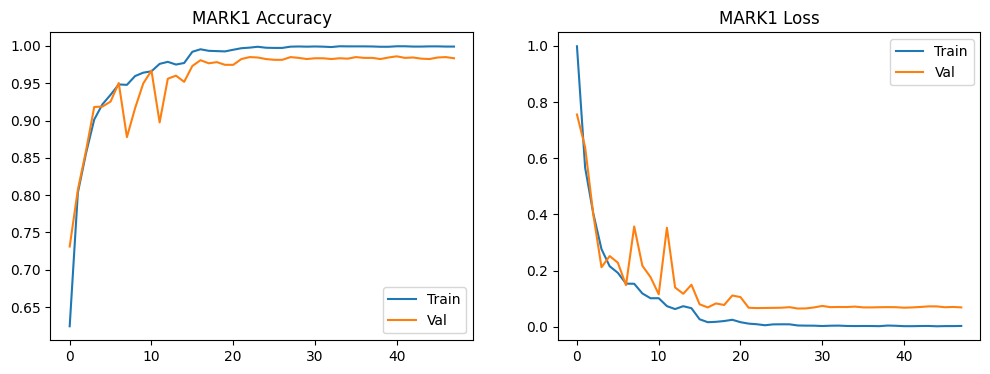

 MARK1 on Test Set...
Test Accuracy: 0.9573
Results will be saved in: /content/drive/MyDrive/brain_tumor/models/MARK1_0.9573


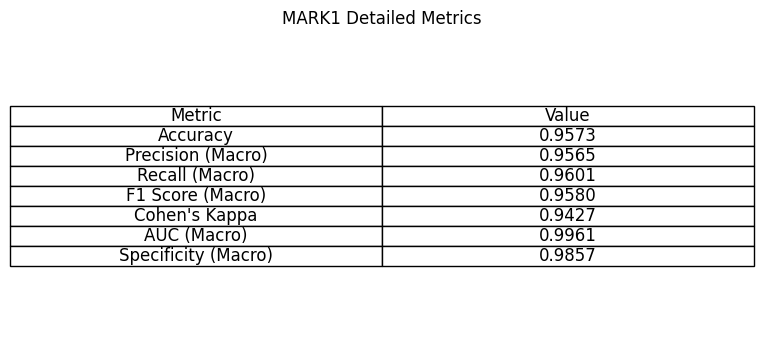

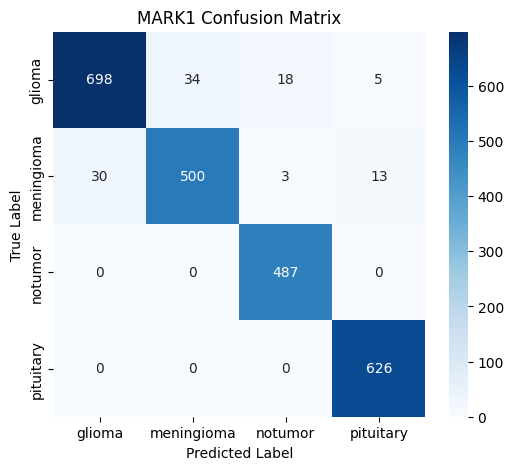

              precision    recall  f1-score   support

      glioma       0.96      0.92      0.94       755
  meningioma       0.94      0.92      0.93       546
     notumor       0.96      1.00      0.98       487
   pituitary       0.97      1.00      0.99       626

    accuracy                           0.96      2414
   macro avg       0.96      0.96      0.96      2414
weighted avg       0.96      0.96      0.96      2414

History plot saved to /content/drive/MyDrive/brain_tumor/models/MARK1_0.9573/history.png


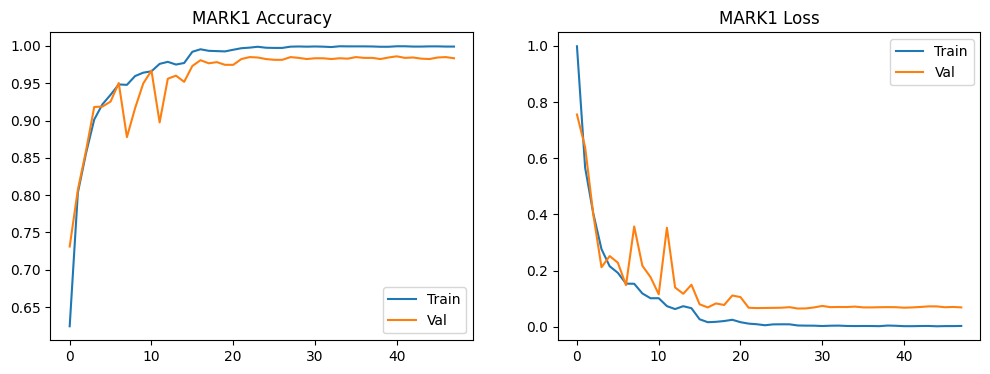

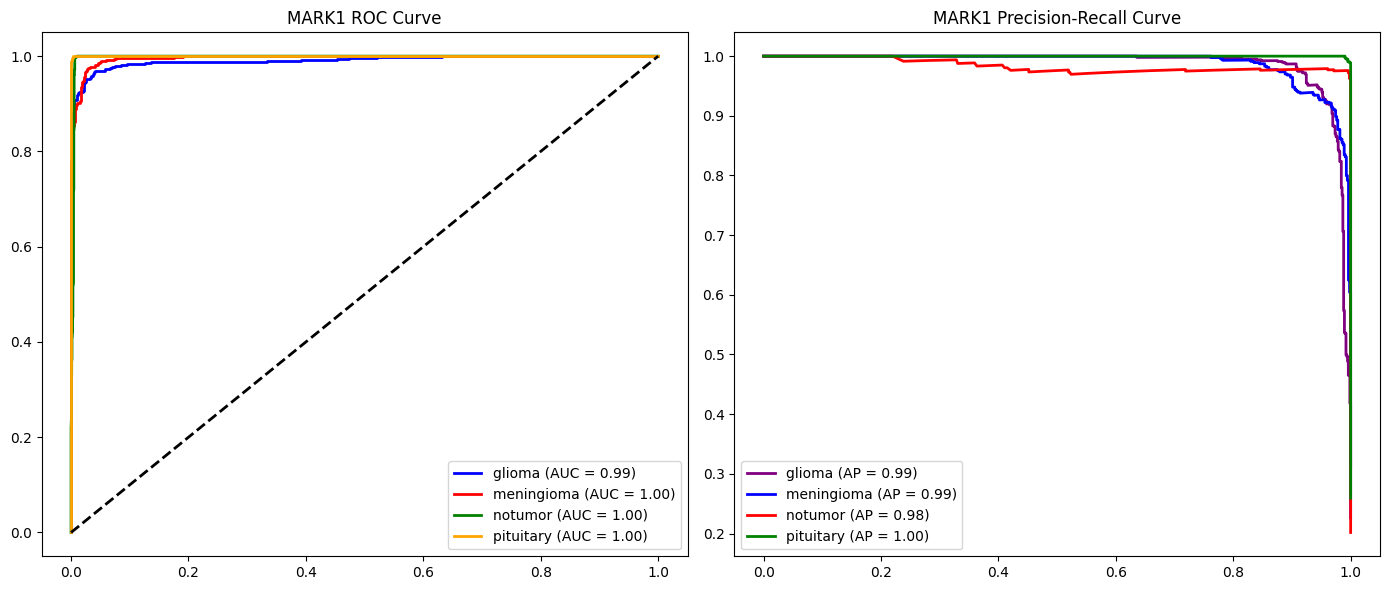

Saving MARK1 with TorchScript (JIT)...
Model saved successfully to /content/drive/MyDrive/brain_tumor/models/MARK1_0.9573/MARK1_jit.pt


In [75]:
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, cohen_kappa_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import seaborn as sns
from itertools import cycle
import torch
import numpy as np


def plot_history(hist, title, save_path=None):
    """Eğitim geçmişini görselleştir
    
    Eğitim ve doğrulama için accuracy ve loss grafiklerini yan yana çizer.
    
    Args:
        hist: Eğitim geçmişi sözlüğü (train_acc, val_acc, train_loss, val_loss)
        title: Grafik başlığı (model adı)
        save_path: Grafiğin kaydedileceği dosya yolu (opsiyonel)
    """
    plt.figure(figsize=(12, 4))

    # ---------- ACCURACY GRAFİĞİ ----------
    plt.subplot(1, 2, 1)
    plt.plot(hist["train_acc"], label="Train", color='blue')
    plt.plot(hist["val_acc"], label="Val", color='orange')
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Val"])
    plt.grid(True, alpha=0.3)

    # ---------- LOSS GRAFİĞİ ----------
    plt.subplot(1, 2, 2)
    plt.plot(hist["train_loss"], label="Train", color='blue')
    plt.plot(hist["val_loss"], label="Val", color='orange')
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Val"])
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Dosyaya kaydet (opsiyonel)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"History plot saved to {save_path}")

    plt.show()


def evaluate_model(model, loader, name, history=None):
    """
    Model değerlendirme ve sonuç raporlama fonksiyonu
    Test seti üzerinde modeli değerlendirir ve kapsamlı metrikler hesaplar.
    Sonuçları görselleştirir ve dosyaya kaydeder.
    """
    # Modeli değerlendirme moduna al
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    # ==================== TAHMİN AŞAMASI ====================
    with torch.no_grad():  # Gradyan hesaplama kapalı (bellek tasarrufu)
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            # İleri yayılım
            out = model(x)
            
            # Softmax ile olasılık dağılımı
            prob = torch.softmax(out, dim=1)

            # Sonuçları biriktir
            y_true.extend(y.cpu().numpy())
            y_pred.extend(torch.argmax(out, 1).cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    # ==================== METRİK HESAPLAMA ====================
    # Temel metrikler
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)

    # AUC hesaplama (çok sınıflı için binarize gerekli)
    try:
        y_true_bin = label_binarize(y_true, classes=range(num_classes))
        auc_val = roc_auc_score(y_true_bin, np.array(y_prob), multi_class='ovr', average='macro')
    except Exception as e:
        print(f"AUC Calculation Error: {e}")
        auc_val = 0

    # Confusion matrix ve Specificity hesaplama
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for i in range(num_classes):
        # True Negative: Toplam - (satır toplamı + sütun toplamı - doğru tahmin)
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        # False Positive: Sütun toplamı - doğru tahmin
        fp = np.sum(cm[:, i]) - cm[i, i]
        # Specificity: TN / (TN + FP)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    avg_spec = np.mean(specificities)

    print(f"Test Accuracy: {acc:.4f}")

    # ==================== KAYIT KLASÖRÜ OLUŞTUR ====================
    base_save_dir = "/content/drive/MyDrive/brain_tumor/models"
    folder_name = os.path.join(base_save_dir, f"{name}_{acc:.4f}")
    os.makedirs(folder_name, exist_ok=True)
    print(f"Results will be saved in: {folder_name}")

    # ==================== METRİK TABLOSU ====================
    metrics_data = {
        "Metric": [
            "Accuracy", 
            "Precision (Macro)", 
            "Recall (Macro)", 
            "F1 Score (Macro)", 
            "Cohen's Kappa", 
            "AUC (Macro)", 
            "Specificity (Macro)"
        ],
        "Value": [
            f"{acc:.4f}", 
            f"{prec:.4f}", 
            f"{rec:.4f}", 
            f"{f1:.4f}", 
            f"{kappa:.4f}", 
            f"{auc_val:.4f}", 
            f"{avg_spec:.4f}"
        ]
    }
    df_metrics = pd.DataFrame(metrics_data)

    # Metrik tablosunu görselleştir
    plt.figure(figsize=(8, 4))
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(
        cellText=df_metrics.values, 
        colLabels=df_metrics.columns, 
        cellLoc='center', 
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.2)
    plt.title(f"{name} Detailed Metrics")
    plt.savefig(os.path.join(folder_name, 'metrics_table.png'), bbox_inches='tight', dpi=150)
    plt.show()

    # ==================== CONFUSION MATRIX ====================
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(folder_name, 'confusion_matrix.png'), dpi=150)
    plt.show()

    # ==================== CLASSIFICATION REPORT ====================
    report = classification_report(y_true, y_pred, target_names=class_names)
    print(report)
    with open(os.path.join(folder_name, 'classification_report.txt'), 'w') as f:
        f.write(f"Model: {name}\n")
        f.write(f"Test Accuracy: {acc:.4f}\n\n")
        f.write(report)

    # ==================== EĞİTİM GEÇMİŞİ GRAFİĞİ ====================
    if history:
        plot_history(history, name, save_path=os.path.join(folder_name, 'history.png'))

    # ==================== ROC VE PR EĞRİLERİ ====================
    y_prob = np.array(y_prob)
    fpr, tpr, roc_auc = {}, {}, {}
    precision, recall, pr_auc = {}, {}, {}

    # Her sınıf için ROC ve PR eğrilerini hesapla
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        pr_auc[i] = average_precision_score(y_true_bin[:, i], y_prob[:, i])

    # ROC ve PR eğrilerini çiz
    plt.figure(figsize=(14, 6))
    
    # ROC Curve
    plt.subplot(1, 2, 1)
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    for i, color in zip(range(num_classes), colors):
        plt.plot(recall[i], precision[i], color=color, lw=2,
                 label=f'{class_names[i]} (AP = {pr_auc[i]:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(folder_name, 'roc_pr_curves.png'), dpi=150)
    plt.show()

    # ==================== MODEL KAYDETME (TorchScript) ====================
    try:
        print(f"Saving {name} with TorchScript (JIT)...")
        dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
        traced_model = torch.jit.trace(model, dummy_input)
        jit_path = os.path.join(folder_name, f"{name}_jit.pt")
        traced_model.save(jit_path)
        print(f"Model saved successfully to {jit_path}")
    except Exception as e:
        print(f"Error saving with JIT: {e}")

    # Bellek temizliği
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ==================== MODEL EĞİTİMİ VE DEĞERLENDİRME ====================
# Eğitim geçmişlerini sakla (notebook yeniden çalıştırıldığında korunsun)
if 'histories' not in globals():
    histories = {}

# Seçili modeli al
selected_name = model_dropdown.value
print(f"Model: {selected_name}")

model = models_dict[selected_name]

print(f"\nTraining {selected_name}")

# Optimizer ve Scheduler tanımla
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',      # val_loss minimize edilecek
    patience=3,      # 3 epoch iyileşme olmazsa lr düşür
    factor=0.5       # lr'ı yarıya düşür
)

# Eğitimi başlat
histories[selected_name] = train_model(model, optimizer, scheduler)

# Eğitim geçmişini görselleştir
plot_history(histories[selected_name], selected_name)

# Test seti üzerinde değerlendir
print(f"Evaluating {selected_name} on Test Set...")
evaluate_model(model, test_loader, selected_name, history=histories.get(selected_name))